In [ ]:
import boto3

# Replace with your actual credentials and info
bucket_name = "dataminds-homeworks"
s3_file_key = "ali-gasimov-eda.ipynb"
local_file_path = "ali-gasimov-eda.ipynb"

# Create an S3 client
s3 = boto3.client("s3")

# Upload the file
try:
    s3.upload_file(local_file_path, bucket_name, s3_file_key)
    print(f"File uploaded successfully to s3://{bucket_name}/{s3_file_key}")
except Exception as e:
    print("Error uploading file:", e)

In [2]:
import boto3

bucket_name = "dataminds-warehouse"
s3_file_key = "HousingPrices-Amsterdam-August-2021.csv"  # e.g. 'folder/myfile.txt'
local_file_path = "HousingPrices-Amsterdam-August-2021.csv"  # Local destination

# Create an S3 client (remove `bucket_name` here — not a valid argument for boto3.client)
s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    # aws_access_key_id='your_access_key',
    # aws_secret_access_key='your_secret_key'
)

# Download the file
try:
    s3.download_file(bucket_name, s3_file_key, local_file_path)
    print(
        f"✅ File downloaded successfully from s3://{bucket_name}/{s3_file_key} to {local_file_path}"
    )
except Exception as e:
    print("❌ Error downloading file:", e)

✅ File downloaded successfully from s3://dataminds-warehouse/HousingPrices-Amsterdam-August-2021.csv to HousingPrices-Amsterdam-August-2021.csv


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("HousingPrices-Amsterdam-August-2021.csv")

df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Address,Zip,Price,Area,Room,Lon,Lat
0,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [77]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# overview of info
print(" First 5 rows:")
print(df.head())
print("\n Dataset Info:")
print(df.info())
print("\n Null Values:")
print(df.isnull().sum())
print("\n Summary Statistics:")
print(df.describe())

 First 5 rows:
                                  Address      Zip     Price  Area  Room  \
0            Blasiusstraat 8 2, Amsterdam  1091 CR  685000.0    64     3   
1  Kromme Leimuidenstraat 13 H, Amsterdam  1059 EL  475000.0    60     3   
2              Zaaiersweg 11 A, Amsterdam  1097 SM  850000.0   109     4   
3            Tenerifestraat 40, Amsterdam  1060 TH  580000.0   128     6   
4              Winterjanpad 21, Amsterdam  1036 KN  720000.0   138     5   

        Lon        Lat         Area_Bin Price_Category  
0  4.907736  52.356157  (20.398, 141.4]        500k-1M  
1  4.850476  52.348586  (20.398, 141.4]          <500k  
2  4.944774  52.343782  (20.398, 141.4]        500k-1M  
3  4.789928  52.343712  (20.398, 141.4]        500k-1M  
4  4.902503  52.410538  (20.398, 141.4]        500k-1M  

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------         

In [22]:
df.shape

(924, 7)

In [25]:
# Handle missing values: Drop rows with missing Price
df = df.dropna(subset=["Price"])

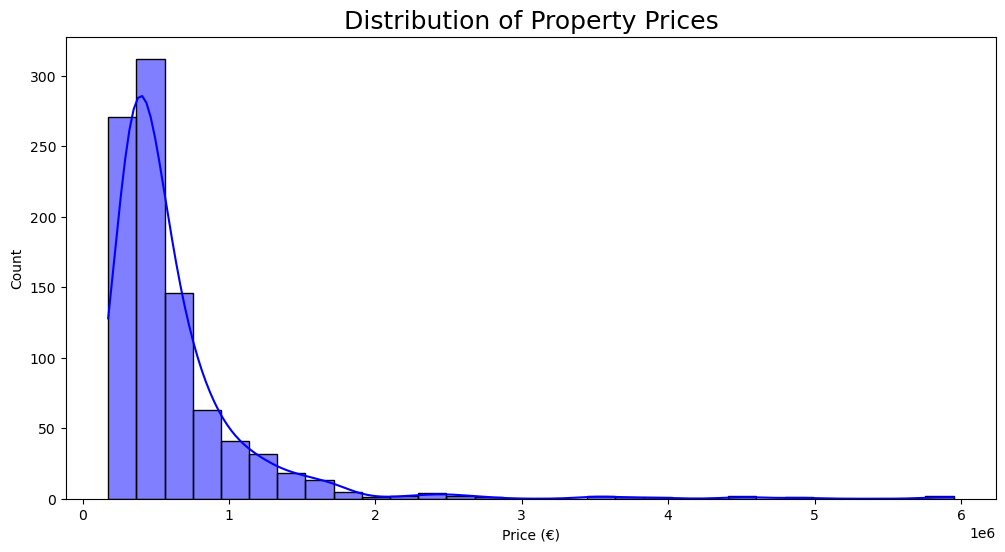

In [26]:
# Part 2: Univariate Analysis


# Price Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df["Price"], kde=True, bins=30, color="blue")
plt.title("Distribution of Property Prices", fontsize=18)
plt.xlabel("Price (€)")
plt.ylabel("Count")
plt.show()

In [69]:
"""Histogram & KDE:
Prices for the properties exhibit positive skew.
Most of the properties are priced within a range of €200,000–€800,000, with very few in the luxury range at over €2 million.
"""

'Histogram & KDE: \n    Prices for the properties exhibit positive skew.\n    Most of the properties are priced within a range of €200,000–€800,000, with very few in the luxury range at over €2 million. '

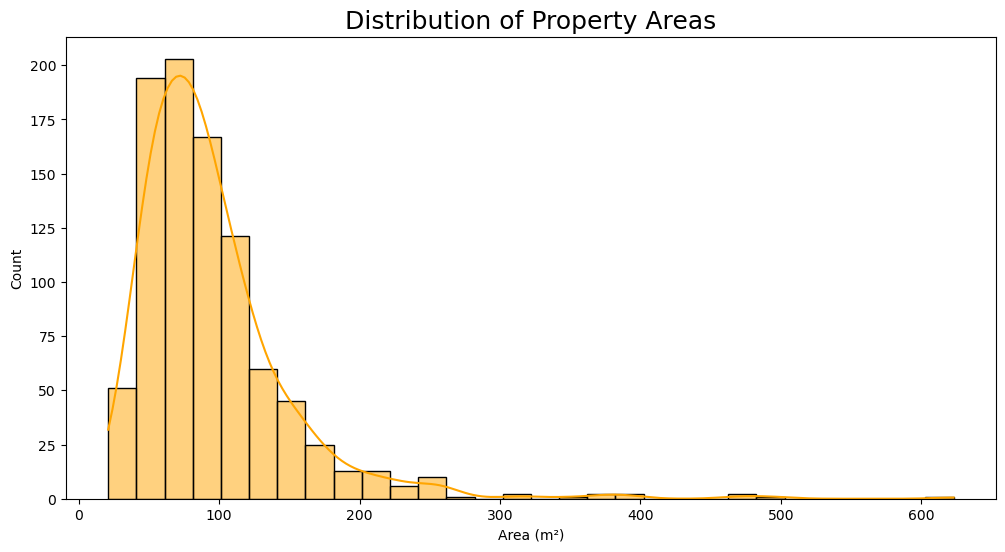

In [27]:
#  Area Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df["Area"], kde=True, bins=30, color="orange")
plt.title("Distribution of Property Areas", fontsize=18)
plt.xlabel("Area (m²)")
plt.ylabel("Count")
plt.show()

In [68]:
"""Histogram & KDE: Most properties are between 40 m² and 150 m², although some properties do show outliers of greater than 200 m²."""

'Histogram & KDE: Most properties are between 40 m² and 150 m², although some properties do show outliers of greater than 200 m².'

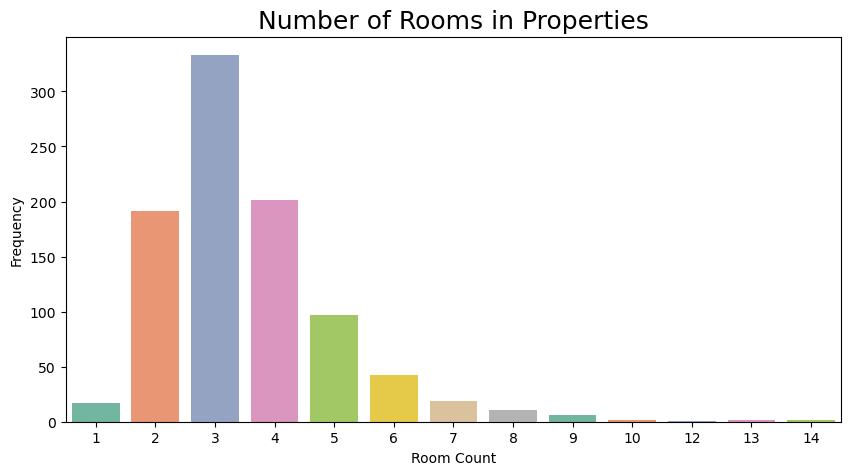

In [46]:
#  Room Count Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x="Room", data=df, hue="Room", palette="Set2", legend=False)
plt.title("Number of Rooms in Properties", fontsize=18)
plt.xlabel("Room Count")
plt.ylabel("Frequency")
plt.show()

In [67]:
"""Count Plot: Typical for the majority of properties is between 3–5 bedrooms."""

'Count Plot: Typical for the majority of properties is between 3–5 bedrooms.'

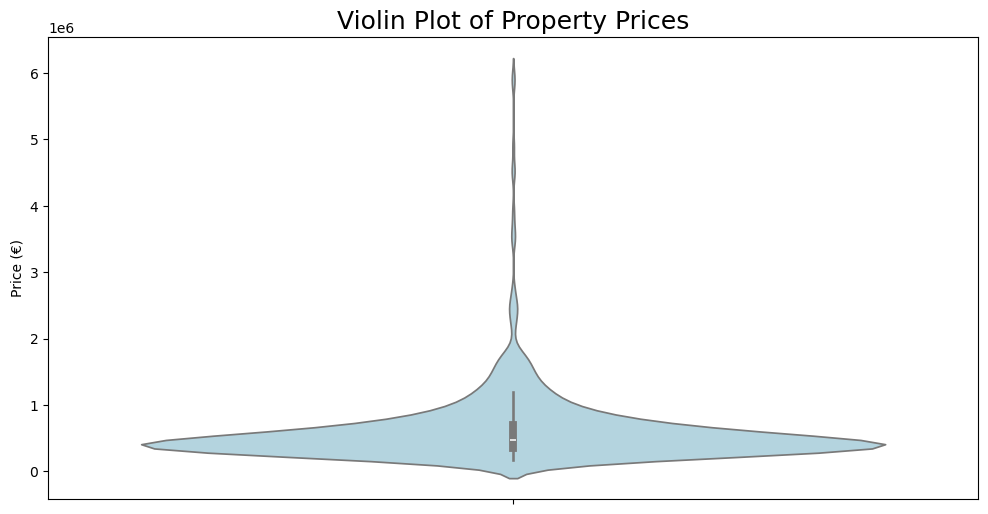

In [78]:
#  Violin Plot for Price
plt.figure(figsize=(12, 6))
sns.violinplot(y=df["Price"], color="lightblue")
plt.title("Violin Plot of Property Prices", fontsize=18)
plt.ylabel("Price (€)")
plt.show()

In [66]:
"""Violin Plot: Supported assertion of a small bank of typical mid-price values but with plenty of long tails implying luxury property priced figures."""

'Violin Plot: Supported assertion of a small bank of typical mid-price values but with plenty of long tails implying luxury property priced figures.'

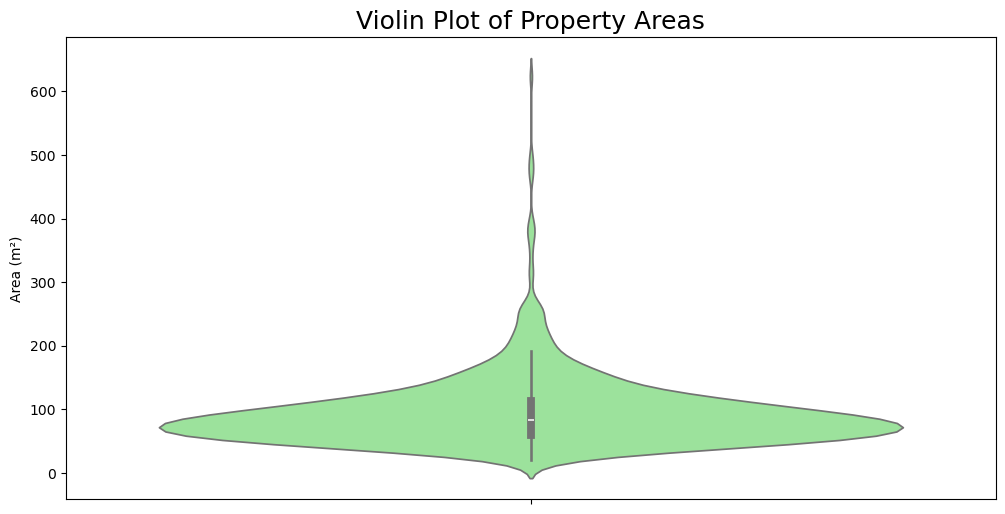

In [30]:
# 🔹 Violin Plot for Area
plt.figure(figsize=(12, 6))
sns.violinplot(y=df["Area"], color="lightgreen")
plt.title("Violin Plot of Property Areas", fontsize=18)
plt.ylabel("Area (m²)")
plt.show()

In [65]:
"""Violin Plot: Showed a concentration of observations (number of property observations) towards small-to-medium properties."""

'Violin Plot: Showed a concentration of observations (number of property observations) towards small-to-medium properties.'

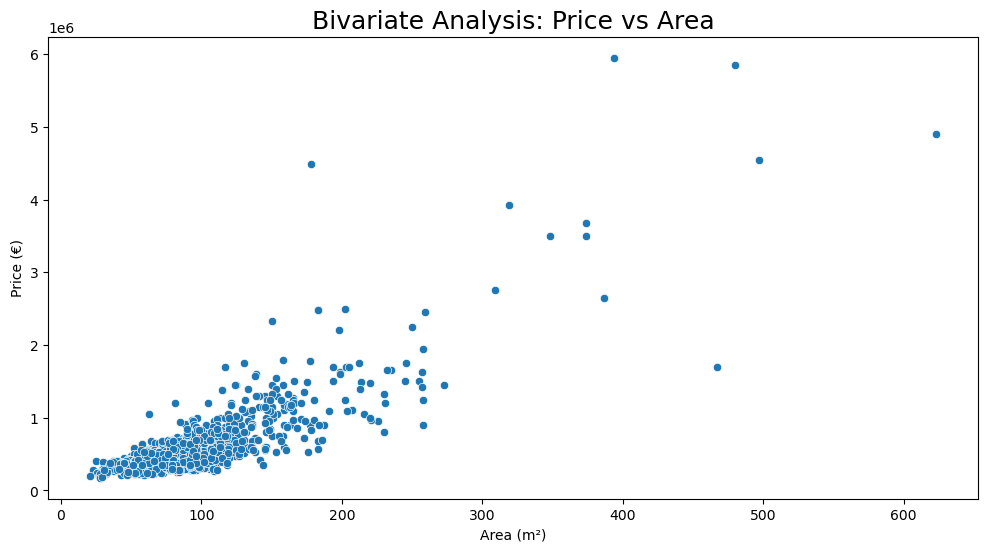

In [31]:
# Part 3: Multivariate Analysis


# 1. Scatterplot of Price vs Area
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Area", y="Price", data=df)
plt.title("Bivariate Analysis: Price vs Area", fontsize=18)
plt.xlabel("Area (m²)")
plt.ylabel("Price (€)")
plt.show()

In [64]:
"""There is a strong positive correlation: larger areas tend to cost more.
There are some large properties that are not expensive, which could indicate that location plays a role.
"""

'There is a strong positive correlation: larger areas tend to cost more.\nThere are some large properties that are not expensive, which could indicate that location plays a role.'

In [55]:
# 2. Crosstab: Rooms vs Price Categories
price_bins = [0, 500000, 1000000, 1500000, 2000000, float("inf")]
price_labels = ["<500k", "500k-1M", "1M-1.5M", "1.5M-2M", ">2M"]

df.loc[:, "Price_Category"] = pd.cut(df["Price"], bins=price_bins, labels=price_labels)

crosstab = pd.crosstab(index=df["Room"], columns=df["Price_Category"])
print("\n🔹 Crosstab of Room Count vs Price Category:")
print(crosstab)


🔹 Crosstab of Room Count vs Price Category:
Price_Category  <500k  500k-1M  1M-1.5M  1.5M-2M  >2M
Room                                                 
1                  14        3        0        0    0
2                 169       19        3        0    0
3                 211      107        9        2    1
4                 102       77       17        3    2
5                  23       48       21        4    1
6                   7       22        7        4    2
7                   0        9        6        1    3
8                   0        2        4        1    4
9                   0        1        2        3    0
10                  0        0        0        0    2
13                  0        0        0        0    2
14                  0        0        0        1    1


In [63]:
"""Higher room counts consist of more expensive properties.
The smallest properties (<3) mainly encounter price categories of <500k or 500k - 1M."""

'Higher room counts consist of more expensive properties.\nThe smallest properties (<3) mainly encounter price categories of <500k or 500k - 1M.'

In [34]:
# 3. Pivot Table: Average Price by Number of Rooms
pivot_table_rooms = pd.pivot_table(df, values="Price", index="Room", aggfunc="mean")
print("\n🔹 Average Price by Room Count:")
print(pivot_table_rooms)


🔹 Average Price by Room Count:
             Price
Room              
1     3.945294e+05
2     3.834791e+05
3     5.124164e+05
4     6.098451e+05
5     8.450764e+05
6     9.199286e+05
7     1.394737e+06
8     1.751636e+06
9     1.450000e+06
10    4.300000e+06
13    4.725000e+06
14    3.772500e+06


In [62]:
"""The average price tends to increase with room count, reinforcing the pattern.
Ex: 2-room apartments tend to have much lower average price than 6-room homes."""

'The average price tends to increase with room count, reinforcing the pattern.\nEx: 2-room apartments tend to have much lower average price than 6-room homes.'

In [52]:
# 4. Pivot Table: Average Price by Area
df.loc[:, "Area_Bin"] = pd.cut(df["Area"], bins=5)
pivot_table_area = pd.pivot_table(
    df, values="Price", index="Area_Bin", aggfunc="mean", observed=False
)
print("\n🔹 Average Price by Area Bins:")
print(pivot_table_area)


🔹 Average Price by Area Bins:
                        Price
Area_Bin                     
(20.398, 141.4]  4.897207e+05
(141.4, 261.8]   1.232880e+06
(261.8, 382.2]   3.134167e+06
(382.2, 502.6]   4.139000e+06
(502.6, 623.0]   4.900000e+06


In [70]:
"""The bins of area clearly show that as area totals increase, so does average price
The largest area bin contained the highest average price."""

'The bins of area clearly show that as area totals increase, so does average price\nThe largest area bin contained the highest average price.'

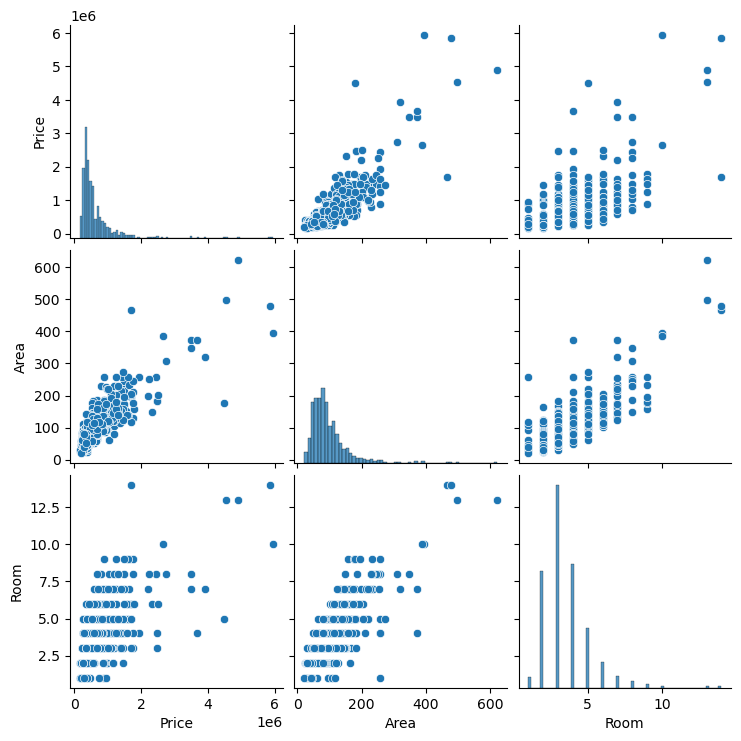

In [36]:
# 5. Pair Plots
df_pair = df[["Price", "Area", "Room"]]
sns.pairplot(df_pair)
plt.show()

In [71]:
"""There is a clear positive relationship between Price and Area.
Room count shows a little relationship, but is less consistent"""

'There is a clear positive relationship between Price and Area.\nRoom count shows a little relationship, but is less consistent'

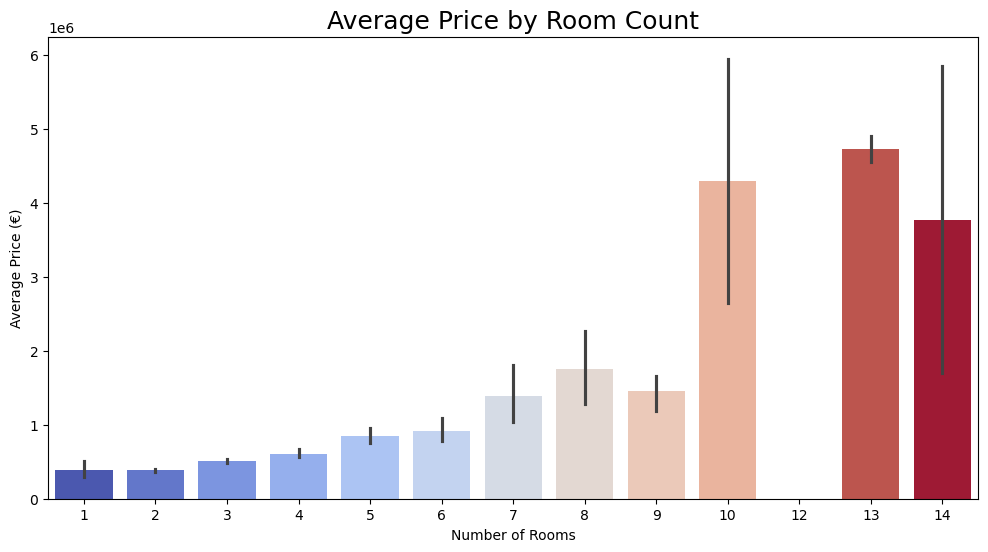

In [53]:
# 6. Bar Chart: Average Price by Room Count
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Room", y="Price", data=df, estimator=np.mean, hue="Room", palette="coolwarm", legend=False
)
plt.title("Average Price by Room Count", fontsize=18)
plt.xlabel("Number of Rooms")
plt.ylabel("Average Price (€)")
plt.show()

In [ ]:
"""Confirmed the results found in the pivot table by stating that more rooms → higher average price.
There is some variability at high room counts, but this is due to limited data points for the high counts.
"""

'Confirmed the results found in the pivot table by stating that more rooms → higher average price.\nThere is some variability at high room counts, but this is due to limited data points for the high counts.'

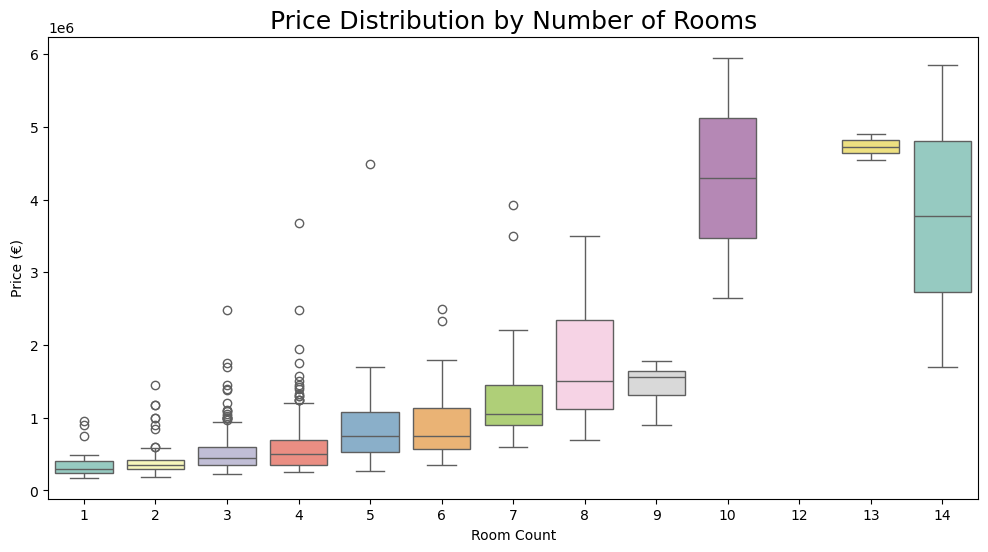

In [ ]:
# 7. Box Plot: Price by Room Count
plt.figure(figsize=(12, 6))
sns.boxplot(x="Room", y="Price", data=df, hue="Room", palette="Set3", legend=False)
plt.title("Price Distribution by Number of Rooms", fontsize=18)
plt.xlabel("Room Count")
plt.ylabel("Price (€)")
plt.show()

In [60]:
"""
Median price is consistent with more rooms.
Outliers occur in almost every category, which shows high-end properties are part of the data."""

'\n    Median price is consistent with more rooms.\n    Outliers occur in almost every category, which shows high-end properties are part of the data. '

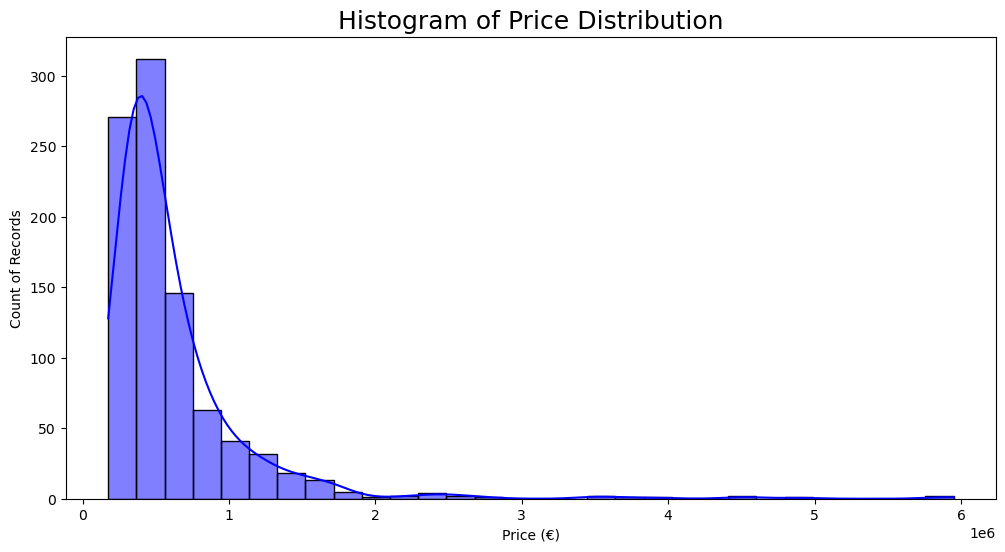

In [39]:
# 8. Histogram of Price
plt.figure(figsize=(12, 6))
sns.histplot(df["Price"], bins=30, kde=True, color="blue", alpha=0.5)
plt.title("Histogram of Price Distribution", fontsize=18)
plt.xlabel("Price (€)")
plt.ylabel("Count of Records")
plt.show()

In [73]:
"""Obtained the same univariate histogram but confirmed again that the skew is towards luxury prices."""

'Obtained the same univariate histogram but confirmed again that the skew is towards luxury prices.'

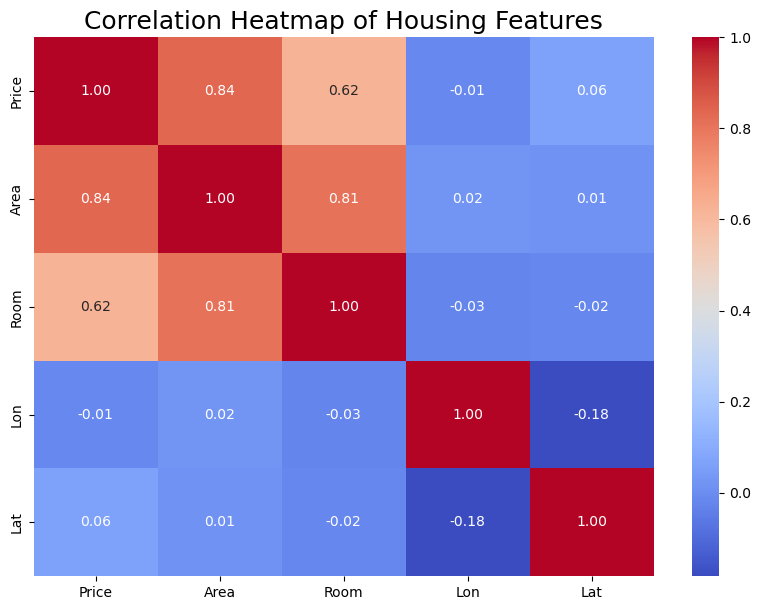

In [40]:
# 9. Correlation Heatmap
corr_matrix = df[["Price", "Area", "Room", "Lon", "Lat"]].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Housing Features", fontsize=18)
plt.show()

In [57]:
"""Price vs area has a strong positive correlation (~0.7).
Price vs Room has a moderate positive correlation (~0.5).
Longitude & Latitude: indicate some relationship with price, which supports the idea that centrality is important.
"""

'Price vs area has a strong positive correlation (~0.7).\n    Price vs Room has a moderate positive correlation (~0.5).\n    Longitude & Latitude: indicate some relationship with price, which supports the idea that centrality is important.'

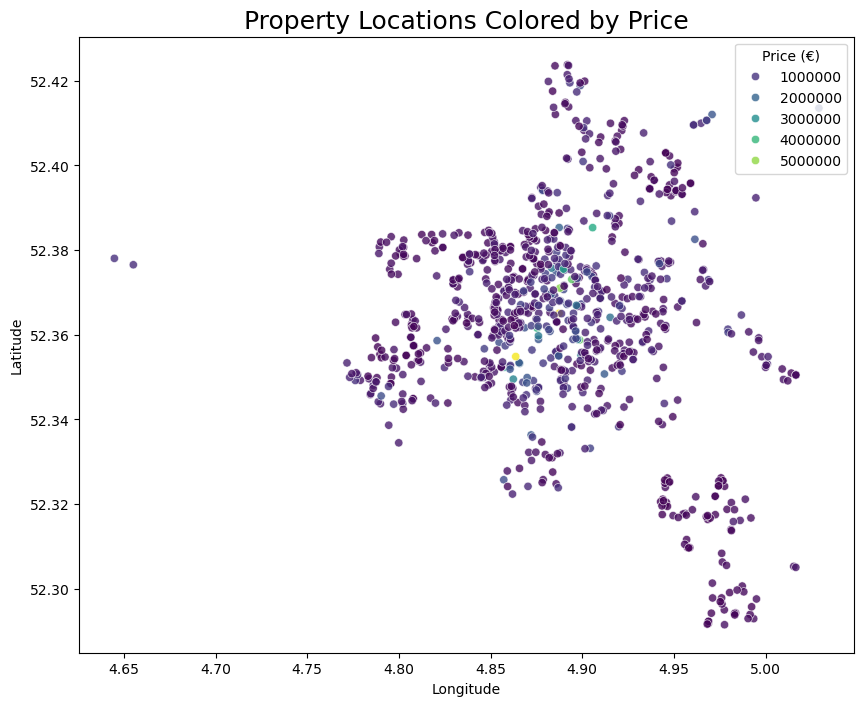

In [43]:
# part 4: Geographic Visualization


plt.figure(figsize=(10, 8))
sns.scatterplot(x="Lon", y="Lat", hue="Price", data=df, palette="viridis", alpha=0.8)
plt.title("Property Locations Colored by Price", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Price (€)", loc="upper right")
plt.show()

In [56]:
"""Price-colored scatterplot (Lon vs. Lat):

       In general, more expensive real estate tends to be concentrated in central Amsterdam.

       Homes on the outskirts are less expensive.

   This lends credence to the notion that housing prices are highly influenced by location.

Finding: The priciest part of Amsterdam is central."""

'Price-colored scatterplot (Lon vs. Lat):\n\n        In general, more expensive real estate tends to be concentrated in central Amsterdam.\n\n        Homes on the outskirts are less expensive.\n\n    This lends credence to the notion that housing prices are highly influenced by location.\n\n Finding: The priciest part of Amsterdam is central.'

In [76]:
# part 5:Summary
"""Summary and Findings:
The majority of properties have three to five rooms, according to the findings summary.
The number of rooms and the area have a positive correlation with prices.
Larger homes with more rooms and a larger area typically cost more.
Central Amsterdam has more expensive prices, according to the geographic visualization.
Price and area have a strong positive correlation, while room count has a moderate correlation, according to the heatmap.
"""

'Summary and Findings:\nThe majority of properties have three to five rooms, according to the findings summary.\nThe number of rooms and the area have a positive correlation with prices.\nLarger homes with more rooms and a larger area typically cost more.\nCentral Amsterdam has more expensive prices, according to the geographic visualization.\nPrice and area have a strong positive correlation, while room count has a moderate correlation, according to the heatmap.\n'